shape: (66_989, 6)
┌────────┬────────┬────────┬─────────┬───────────┬─────────────────┐
│ chr    ┆ start  ┆ end    ┆ smt_pos ┆ smt_value ┆ fuzziness_score │
│ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---       ┆ ---             │
│ str    ┆ i64    ┆ i64    ┆ i64     ┆ f64       ┆ f64             │
╞════════╪════════╪════════╪═════════╪═══════════╪═════════════════╡
│ chrI   ┆ 80     ┆ 228    ┆ 154     ┆ 160.0     ┆ 62.229963       │
│ chrI   ┆ 183    ┆ 331    ┆ 257     ┆ 560.0     ┆ 51.164821       │
│ chrI   ┆ 343    ┆ 491    ┆ 417     ┆ 560.0     ┆ 51.520939       │
│ chrI   ┆ 463    ┆ 611    ┆ 537     ┆ 160.0     ┆ 63.879253       │
│ chrI   ┆ 591    ┆ 739    ┆ 665     ┆ 160.0     ┆ 68.714923       │
│ …      ┆ …      ┆ …      ┆ …       ┆ …         ┆ …               │
│ chrXVI ┆ 942744 ┆ 942892 ┆ 942818  ┆ 56240.0   ┆ 42.835329       │
│ chrXVI ┆ 943093 ┆ 943241 ┆ 943167  ┆ 8080.0    ┆ 44.624281       │
│ chrXVI ┆ 943256 ┆ 943404 ┆ 943330  ┆ 3680.0    ┆ 52.267879       │
│ chrXVI ┆ 9462

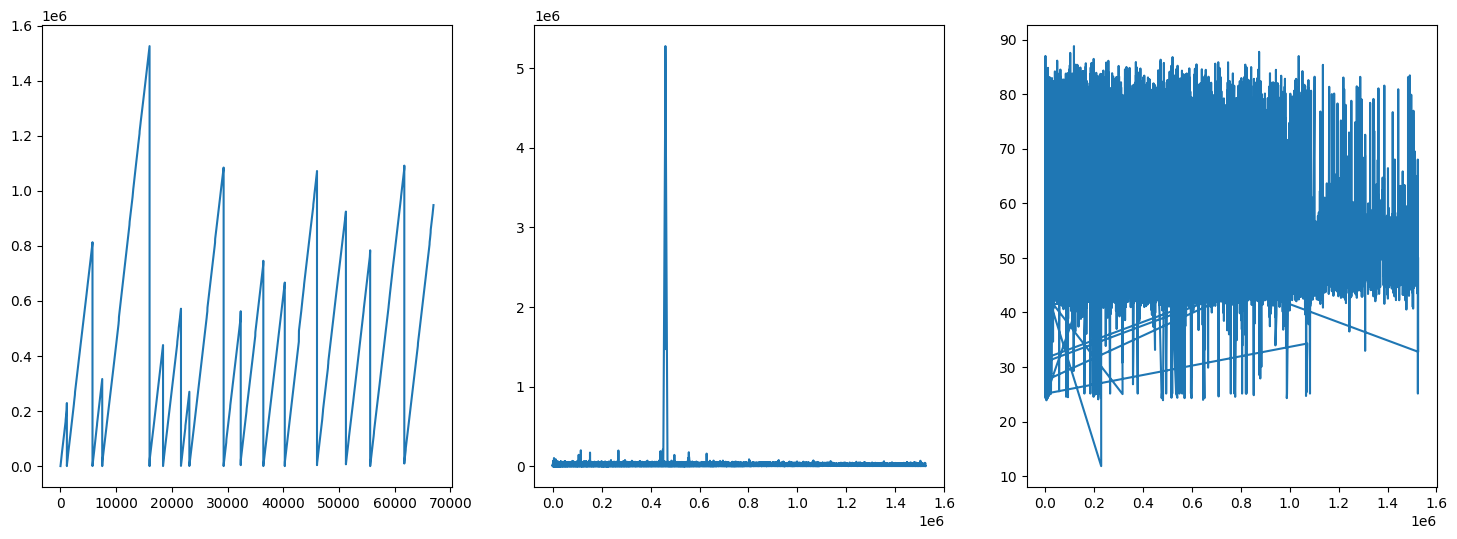

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import polars as pl

from nucleo.metrics.utils import clc_distrib


# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_all = pl.read_csv(
    root,
    separator="\t"
)
print(df_all)


# ── Values ───────────────────────────────────────────────────────────────
CHROMOSOMES     = df_all["chr"].to_numpy()
SMT_POS         = df_all["smt_pos"].to_numpy()
SMT_VALUE       = df_all["smt_value"].to_numpy()
FUZZINESS_SCORE = df_all["fuzziness_score"].to_numpy()
NRLS            = np.diff(df_all["smt_pos"].to_numpy())


# ── Functions ───────────────────────────────────────────────────────────────
def select_region(df, chrom=None, region=None, gap=np.inf):
    condition = pl.col("smt_value") < gap
    if chrom is not None:
        condition &= pl.col("chr") == chrom
    if region is not None:
        condition &= pl.col("smt_pos").is_between(*region)
    return df.filter(condition)

def clc_fuziness_distrib(df: pl.DataFrame):
    fuzziness_score = df["fuzziness_score"].to_numpy()
    return (clc_distrib(
        data=fuzziness_score,
        first_bin=np.min(fuzziness_score),
        last_bin=np.max(fuzziness_score),
        bin_width=1
        )
    )

def clc_NRLs_distrib(df: pl.DataFrame, NRLS: np.ndarray):
    return(clc_distrib(
        data=NRLS,
        first_bin=np.min(NRLS),
        last_bin=np.max(NRLS),
        bin_width=1
        )
    )


# ── Plots over all the genome + Raw values ───────────────────────────────────────────────────────────────
fig, (ax0, ax1, ax2) = plt.subplots(figsize=(18,6), ncols=3, nrows=1)
ax0.plot(SMT_POS)
ax1.plot(SMT_POS, SMT_VALUE)
ax2.plot(SMT_POS, FUZZINESS_SCORE)
plt.show()


# ─ Nous sommes obligés de compartimenter par chromosome sinon ça n'a aucun sens ───────────────────────────────────────────────────────────────


shape: (28, 7)
┌───────┬────────┬────────┬─────────┬───────────┬─────────────────┬──────┐
│ chr   ┆ start  ┆ end    ┆ smt_pos ┆ smt_value ┆ fuzziness_score ┆ NRLs │
│ ---   ┆ ---    ┆ ---    ┆ ---     ┆ ---       ┆ ---             ┆ ---  │
│ str   ┆ i64    ┆ i64    ┆ i64     ┆ f64       ┆ f64             ┆ i64  │
╞═══════╪════════╪════════╪═════════╪═══════════╪═════════════════╪══════╡
│ chrII ┆ 250046 ┆ 250194 ┆ 250120  ┆ 27920.0   ┆ 49.93494        ┆ 0    │
│ chrII ┆ 250206 ┆ 250354 ┆ 250280  ┆ 19200.0   ┆ 56.326189       ┆ 160  │
│ chrII ┆ 250361 ┆ 250509 ┆ 250435  ┆ 30800.0   ┆ 49.229435       ┆ 155  │
│ chrII ┆ 250521 ┆ 250669 ┆ 250595  ┆ 30720.0   ┆ 50.194767       ┆ 160  │
│ chrII ┆ 250680 ┆ 250828 ┆ 250754  ┆ 27760.0   ┆ 50.488028       ┆ 159  │
│ …     ┆ …      ┆ …      ┆ …       ┆ …         ┆ …               ┆ …    │
│ chrII ┆ 253976 ┆ 254124 ┆ 254050  ┆ 29200.0   ┆ 49.97341        ┆ 157  │
│ chrII ┆ 254141 ┆ 254289 ┆ 254215  ┆ 24720.0   ┆ 52.38293        ┆ 165  │
│ chrII ┆ 

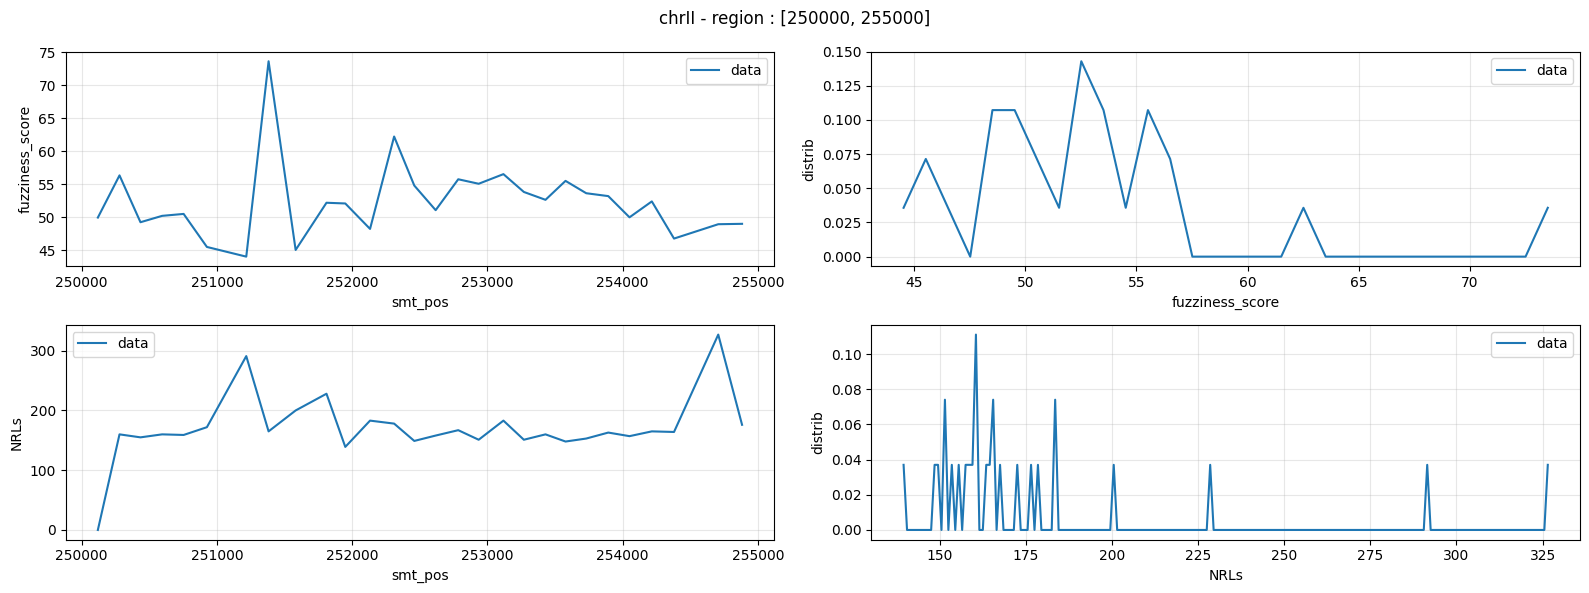

In [25]:
# ── Region ───────────────────────────────────────────────────────────────
chrom   = "chrII"
region  = [250_000, 255_000]
gap     = 1e4

df_region = select_region(
    df_all,
    chrom=chrom,
    region = region,
    gap=1e6,
)

df_region = df_region.with_columns(
    NRLs = np.concatenate(([0], np.diff(df_region["smt_pos"].to_numpy())))
)

print(df_region)


# ── Plots on one specific region + Distributions ───────────────────────────────────────────────────────────────
x1, y1 = df_region["smt_pos"], df_region["fuzziness_score"]
x2, y2 = clc_fuziness_distrib(df_region)
x3, y3 = df_region["smt_pos"], df_region["NRLs"]
x4, y4 = clc_NRLs_distrib(df_region)


# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, figsize=(16, 6))
fig.suptitle(f"{chrom} - region : {region}")

ax1.plot(x1, y1, label="data")
ax1.set_xlabel("smt_pos")
ax1.set_ylabel("fuzziness_score")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc="best")

ax2.plot(x2, y2, label="data")
ax2.set_xlabel("fuzziness_score")
ax2.set_ylabel("distrib")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(loc="best")

ax3.plot(x3, y3, label="data")
ax3.set_xlabel("smt_pos")
ax3.set_ylabel("NRLs")
ax3.grid(True, which="both", alpha=0.3)
ax3.legend(loc="best")

ax4.plot(x4, y4, label="data")
ax4.set_xlabel("NRLs")
ax4.set_ylabel("distrib")
ax4.grid(True, which="both", alpha=0.3)
ax4.legend(loc="best")

plt.tight_layout()
plt.show()

# .